In [1]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
import matplotlib.image as mpimg
from pathlib import Path
import os
import glob
from PIL import Image
from IPython.display import display
from IPython.display import Image as dis_image 
from descartes import PolygonPatch
import alphashape
from shapely.geometry import Point, Polygon
import random
import math
from IPython.display import clear_output
import spacy
import statsmodels.api as sm 
from sklearn.model_selection import train_test_split
from sklearn.metrics import (confusion_matrix, accuracy_score)
import matplotlib.cm 
from matplotlib.colors import LinearSegmentedColormap 
import seaborn as sns

In [2]:
# Load data
results_df = pd.read_table('./data_here/all_results.txt', delimiter='\t')

def read_interest_area(trial_name): #edit for L and R cases
    boundary = []
    subject = ['',[],[]]
    with open("./data_here/interest areas/"+trial_name, "r") as file:
        
        content = file.read()
        bounds = content.split('\n')
        for i in range(2):
            items = bounds[i].split()
            subject[0] = items[-1]
            
            x_coords = []
            y_coords = []
            for coord in items[2:-1]:
                x, y = map(int, coord.split(','))
                x_coords.append(x)
                y_coords.append(y)
                
            subject[1] = x_coords
            subject[2] = y_coords
            boundary.append(subject)
            subject = ['',[],[]]

    return boundary

In [3]:
def get_file_names():

    folder_path = Path("./data_here/interest areas")
    file_names = [file.name for file in folder_path.iterdir() if file.is_file()]

    return file_names

In [4]:
def is_point_in_shape(x1, y1, x2, y2, coord):
    bound1 = list(zip(x1, y1))
    bound2 = list(zip(x2, y2))

    alpha_shape1 = Polygon(bound1)
    alpha_shape2 = Polygon(bound2)
    
    # Debug: Print Polygon Coordinates
    #print(f"Polygon Coordinates: {list(alpha_shape1.exterior.coords)}")
    #print(f"Polygon Coordinates: {list(alpha_shape2.exterior.coords)}")

    point = Point(coord[0], coord[1])

    if alpha_shape1.contains(point):
        area = "bound1"
    elif alpha_shape2.contains(point):
        area = "bound2"
    else:
        area = "empty"

    return area

In [5]:
def plot_trial(x_plots, y_plots, trial_name, num_frames=20, save_folder="plot_images"):
    folder_path = "./plot_images"
    
    for filename in os.listdir(folder_path):
        file_path = os.path.join(folder_path, filename)
        if os.path.isfile(file_path) and filename != ".gitignore":  # Ensure it's a file, not a folder
            os.remove(file_path)
        
    os.makedirs(save_folder, exist_ok=True)
    
    # Filter out None values
    valid_indices = ~np.isnan(x_plots) & ~np.isnan(y_plots)
    x_plots = np.array(x_plots)[valid_indices]
    y_plots = np.array(y_plots)[valid_indices]

    boundary = read_interest_area(trial_name)
    x_bound1 = boundary[0][1]
    x_bound1.append(x_bound1[0])
    y_bound1 = boundary[0][2]
    y_bound1.append(y_bound1[0])
    x_bound2 = boundary[1][1]
    x_bound2.append(x_bound2[0])
    y_bound2 = boundary[1][2]
    y_bound2.append(y_bound2[0])

    # Generate 30 evenly spaced indices
    indices = np.linspace(0, len(x_plots) - 1, num_frames, dtype=int)
    img = mpimg.imread('./data_here/target images/target_girl_taking_cake2_R.bmp')
    height, width, _ = img.shape

    half_width = width / 2
    half_height = height / 2
    xmin = 511 - half_width
    xmax = 511 + half_width
    ymin = 383 - half_height
    ymax = 383 + half_height

    for i in indices:
        plt.figure(figsize=(6, 6), facecolor="white")
        #plt.xlim(0, 1000)
        #plt.ylim(0, 1000)
        
        plt.imshow(img, extent=[xmin, xmax, ymax, ymin], aspect='auto', alpha = 0.3)
        
        plt.plot(x_plots[:i+1], y_plots[:i+1], marker='o', linestyle='-', color='blue', zorder = 3)
        plt.plot(x_bound1, y_bound1, marker='o', linestyle='-', color='red')
        plt.plot(x_bound2, y_bound2, marker='o', linestyle='-', color='green')
        section = is_point_in_shape(x_bound1, y_bound1, x_bound2, y_bound2, [x_plots[i], y_plots[i]])
        if section == "bound1":
            plt.scatter(x_plots[i], y_plots[i], c='red', zorder=4)
        elif section == "bound2":
            plt.scatter(x_plots[i], y_plots[i], c='green', zorder=4)
        plt.xlabel('X Coordinate')
        plt.ylabel('Y Coordinate')
        plt.title('Trial')
        #plt.gca().invert_yaxis()
        plot_filename = os.path.join(save_folder, f"{str(i)}.png")
        plt.savefig(plot_filename, dpi=300, bbox_inches='tight')
        plt.close()

def get_trial_coords(subitem):
    filtered_df = results_df[results_df['subitem'] == subitem]
    x_plots = filtered_df['X_coord'].replace('empty', None).astype(float).tolist()
    y_plots = filtered_df['Y_coord'].replace('empty', None).astype(float).tolist()
    return x_plots, y_plots

def get_trial_name(item):
    picture_name = results_df[results_df['item'] == int(item)]
    pic_name_split = picture_name['picture_name'].unique()[0][:-7].split("_")
    subject1 = pic_name_split[0]
    subject2 = pic_name_split[-1]

    file_names = get_file_names()
    for file in file_names:
        split_file = file.split("_")
        if subject1 in split_file and subject2 in split_file: # This doesn't work, items 3 7 10 17 etc does not have the same subject names
            # Might be able to use agent and patient for this with a bit of editing
            return file

    return None

def show_trial_plot(subitem, frames=20):
    x_coord, y_coord = get_trial_coords(subitem)
    plot_trial(x_coord, y_coord, get_trial_name(subitem[7:]), frames)  
    display_plot_gif("animated_GMM", r"plot_images")
    display(dis_image(filename="saved_gifs/animated_GMM.gif"))

In [6]:
def display_plot_gif(title, img_folder):
    os.makedirs("saved_gifs", exist_ok=True)
    folder_path = "./saved_gifs"
    
    for filename in os.listdir(folder_path):
        file_path = os.path.join(folder_path, filename)
        if os.path.isfile(file_path) and filename != ".gitignore":  # Ensure it's a file, not a folder
            os.remove(file_path)
            
    files = glob.glob(img_folder+r"/*.png")
    files = sorted(files, key=lambda x: int(os.path.splitext(os.path.basename(x))[0]))  # Sort numerically
    
    image_array = []
    progress = 0

    for my_file in files:
        progress += 1
    
        image = Image.open(my_file)
        image_array.append(image)
        #print(progress)

    #print('image_arrays shape:', np.array(image_array).shape())
    #print(type(image_array[2]))
    # Create the figure and axes objects
    fig, ax = plt.subplots()

    # Set the initial image
    im = ax.imshow(image_array[0], animated=True)
    plt.axis('off')

    def update(i):
        im.set_array(image_array[i])
        #print(i)
        return im,

    # Create the animation object
    animation_fig = animation.FuncAnimation(fig, update, frames=len(image_array), interval=200, blit=True,repeat_delay=10,)

    # Show the animation
    #plt.show()

    animation_fig.save("./saved_gifs/"+ title +".gif")
    plt.close()

MovieWriter ffmpeg unavailable; using Pillow instead.


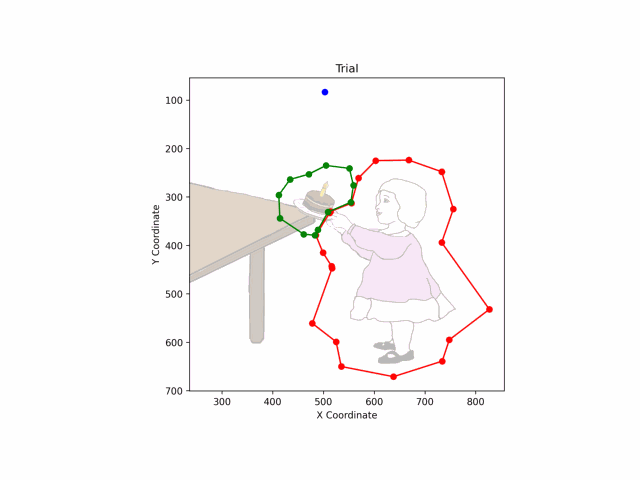

In [11]:
show_trial_plot('sub119_6', 50)
#get_trial_name('25')

In [7]:
#print(results_df['picture_name'].unique())
print(results_df.loc[results_df['item'] == 44, 'picture_name'].unique())


['tiger_scratching_tourist_active']


In [8]:
results_df.loc[results_df['item'] == 6]

,item,subitem,counter,sub,IntAr,X_coord,Y_coord,Time,participant_language,input,...,the1_offset,agent,agent_onset,agent_offset,the2,the2_onset,the2_offset,patient,patient_onset,patient_offset
2000,6,sub101_6,2001,sub101,empty,504.1,100.5,10,L1_participant,L1_input,...,596,girl,596,879,the,1275,1395,cake,1395,1805
2001,6,sub101_6,2002,sub101,empty,504.1,100.5,20,L1_participant,L1_input,...,596,girl,596,879,the,1275,1395,cake,1395,1805
2002,6,sub101_6,2003,sub101,empty,504.1,100.5,30,L1_participant,L1_input,...,596,girl,596,879,the,1275,1395,cake,1395,1805
2003,6,sub101_6,2004,sub101,empty,504.1,100.5,40,L1_participant,L1_input,...,596,girl,596,879,the,1275,1395,cake,1395,1805
2004,6,sub101_6,2005,sub101,empty,504.1,100.5,50,L1_participant,L1_input,...,596,girl,596,879,the,1275,1395,cake,1395,1805
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1729595,6,sub201_6,1884396,sub201,agent,625.1,338.3,3960,BILINGUAL,L2_input,...,727,girl,727,1081,the,1513,1650,cake,1650,2068
1729596,6,sub201_6,1884397,sub201,agent,625.1,338.3,3970,BILINGUAL,L2_input,...,727,girl,727,1081,the,1513,1650,cake,1650,2068
1729597,6,sub201_6,1884398,sub201,agent,625.1,338.3,3980,BILINGUAL,L2_input,...,727,girl,727,1081,the,1513,1650,cake,1650,2068
1729598,6,sub201_6,1884399,sub201,agent,625.1,338.3,3990,BILINGUAL,L2_input,...,727,girl,727,1081,the,1513,1650,cake,1650,2068


In [31]:

def add_colored_text(sentence, num_green_words):
    fig = plt.gcf()
    words = sentence.split()
    
    # Ensure we don't exceed the length of the sentence
    num_green_words = min(num_green_words, len(words))

    # Set the starting position (middle bottom of the figure)
    x_position = 0.12
    y_position = 0.01

    # Get the renderer to calculate text width
    fig.canvas.draw()  # Required to render text properly
    renderer = fig.canvas.get_renderer()

    # Loop through each word and color accordingly
    current_x = x_position
    for i, word in enumerate(words):
        color = "green" if i < num_green_words else "black"

        # Create a text object to measure its size
        text_obj = fig.text(current_x, y_position, word, color=color, fontsize=12, ha='left')
        
        # Measure the text size
        bbox = text_obj.get_window_extent(renderer=renderer)
        text_width = bbox.width / fig.dpi  # Convert from pixels to figure coordinates

        # Move to the next position (with a small padding for spacing)
        current_x += (text_width/6) + 0.01

def get_sentence_timings(item, time, sentence_len):
    the1_offset = results_df[results_df["item"] == item]["the1_offset"].mean()
    agent_offset = results_df[results_df["item"] == item]["agent_offset"].mean()
    the2_offset = results_df[results_df["item"] == item]["the2_offset"].mean()
    patient_offset = results_df[results_df["item"] == item]["patient_offset"].mean()
    the2_onset = results_df[results_df["item"] == item]["the2_onset"].mean()

    if time >= patient_offset:
        return int(sentence_len)
    elif time >= the2_offset:
        return int(sentence_len - 1)
    elif time >= the2_onset:
        return int(sentence_len - 2)
    elif time >= agent_offset:
        return 2
    elif time >= the1_offset:
        return 1
    else:
        return 0

In [74]:
def gen_heatmap_frame(item, timestamp):
    save_folder="heat_images"
    os.makedirs(save_folder, exist_ok=True)

    plt.clf()
    # add alpha (transparency) to a colormap
    wd = matplotlib.cm.winter._segmentdata # only has r,g,b  
    wd['alpha'] =  ((0.0, 0.0, 0.3), 
                   (0.3, 0.3, 1.0),
                   (1.0, 1.0, 1.0))
    
    # modified colormap with changing alpha
    al_winter = LinearSegmentedColormap('AlphaWinter', wd) 
    
    # get the map image as an array so we can plot it 
    map_img = mpimg.imread('./data_here/target images/target_girl_taking_cake2_R.bmp') 

    height, width, _ = map_img.shape

    half_width = width / 2
    half_height = height / 2
    xmin = 511 - half_width
    xmax = 511 + half_width
    ymin = 383 - half_height
    ymax = 383 + half_height

    item_df = results_df.loc[results_df['item'] == item].loc[results_df['participant_language'] == 'BILINGUAL'].loc[results_df['Time'] == timestamp]
    x_vals = item_df['X_coord'].tolist()
    y_vals = item_df['Y_coord'].tolist()
    
    # Ensure both arrays are processed together
    valid_indices = [i for i, (x, y) in enumerate(zip(x_vals, y_vals)) if x != 'empty' and y != 'empty']
    
    x_vals = np.array([float(x_vals[i]) for i in valid_indices])
    y_vals = np.array([float(y_vals[i]) for i in valid_indices])
    
    # Define grid resolution
    resolution = 50
    
    # Create 2D histogram
    heatmap, xedges, yedges = np.histogram2d(x_vals, y_vals, bins=resolution, range=[[0, 1000], [0, 1000]])

    # Calculate scaling factors to map image position to heatmap grid
    x_scale = (xedges[-1] - xedges[0]) / resolution
    y_scale = (yedges[-1] - yedges[0]) / resolution
    
    # Scale the image position to align with the heatmap grid
    xmin_scaled = xmin * (1 / x_scale)
    xmax_scaled = xmax * (1 / x_scale)
    ymin_scaled = ymin * (1 / y_scale)
    ymax_scaled = ymax * (1 / y_scale)

    fig, ax = plt.subplots()
    
    hmax = sns.heatmap(heatmap.T,
                #cmap = al_winter, # this worked but I didn't like it
                cmap = matplotlib.cm.winter,
                alpha = 0.6, # whole heatmap is translucent
                annot = False,
                zorder = 2,
                xticklabels=False, 
                yticklabels=False,
                vmax=5
                )
    
    # heatmap uses pcolormesh instead of imshow, so we can't pass through 
    # extent as a kwarg, so we can't mmatch the heatmap to the map. Instead, 
    # match the map to the heatmap:
    
    hmax.imshow(map_img,
              aspect = hmax.get_aspect(),
              extent = [xmin_scaled, xmax_scaled, ymax_scaled, ymin_scaled],
              zorder = 1) #put the map under the heatmap

    sentence = "The girl grabbed the cake."

    add_colored_text(sentence, num_green_words=get_sentence_timings(item, timestamp, len(sentence.split())))


    plot_filename = os.path.join(save_folder, f"{str(timestamp)}.png")
    #plt.show()
    plt.savefig(plot_filename, dpi=300, bbox_inches='tight')
    plt.close(fig)


def gen_all_HM_frames(item, frame_intervale=10):
    folder_path = "./heat_images"
    
    for filename in os.listdir(folder_path):
        file_path = os.path.join(folder_path, filename)
        if os.path.isfile(file_path) and filename != ".gitignore":  # Ensure it's a file, not a folder
            os.remove(file_path)
        
    os.makedirs("heat_images", exist_ok=True)
    
    item_df = results_df.loc[results_df['item'] == item]
    for i in range(item_df['Time'].min(), item_df['Time'].max()+1, frame_intervale):
        gen_heatmap_frame(item, i)
        print(i, "/", item_df['Time'].max())
        clear_output(wait=True)

    display_plot_gif("animated_heatmap", r"heat_images")
        
    

#gen_heatmap_frame(6, 1600)
#gen_all_HM_frames(6, 100)
#display(dis_image(filename="saved_gifs/animated_heatmap.gif"))

MovieWriter ffmpeg unavailable; using Pillow instead.


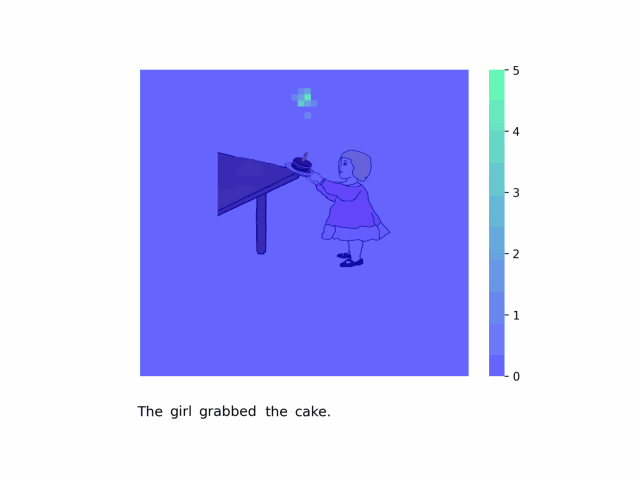

<Figure size 640x480 with 0 Axes>

In [75]:
gen_all_HM_frames(6, 100)
display(dis_image(filename="saved_gifs/animated_heatmap.gif"))

MovieWriter ffmpeg unavailable; using Pillow instead.


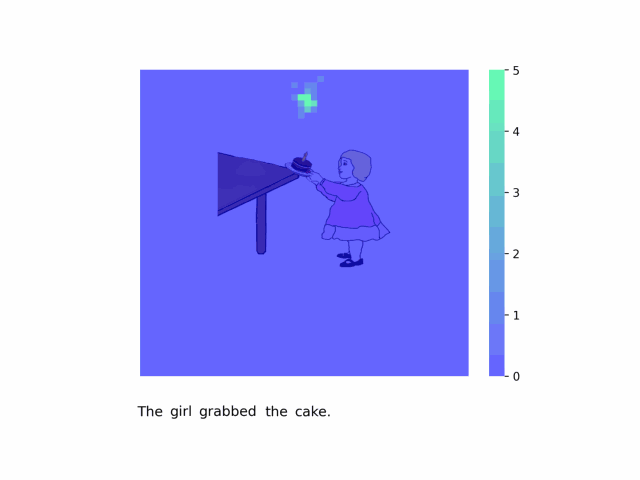

<Figure size 640x480 with 0 Axes>

In [73]:
gen_all_HM_frames(6, 100)
display(dis_image(filename="saved_gifs/animated_heatmap.gif"))

In [ ]:
def create_mapping_file(): # TODO: check about 3 missing boundary files 
    

In [99]:
def get_subitem_data(subitem):
    x_coords, y_coords = get_trial_coords(subitem)
    filtered_df = results_df[results_df['subitem'] == subitem]
    last_area = 'empty'
    area_order = 0
    gaze_shift = 0
    distractions = -1
    distracted = False
    a_dists = []
    b_dists = []
    a_centroid, b_centroid = get_activity_centroids(filtered_df['item'].unique()[0])
    agent_react_time = None
    patient_react_time = None
    agent_leave_time = None
    patient_leave_time = None
    agent_anti_altered = False
    patient_anti_altered = False
    anticipated_agent_onset = False
    anticipated_patient_onset = False

    agent_onset = filtered_df['agent_onset'].unique()[0]
    agent_offset = filtered_df['agent_offset'].unique()[0]
    patient_onset = filtered_df['patient_onset'].unique()[0]
    patient_offset = filtered_df['patient_offset'].unique()[0]
    
    for index, row in filtered_df.iterrows():
        current_area = row['IntAr']
        if last_area == 'agent' and current_area == 'patient':
            area_order = int(1)
            break
        elif last_area == 'patient' and current_area == 'agent':
            area_order = int(2)
            break
        elif current_area != 'empty':
            last_area = current_area

    last_area = 'empty'
    for index, row in filtered_df.iterrows():
        current_area = row['IntAr']
        if row['X_coord'] == 'empty':
            continue
        elif last_area != current_area:
            gaze_shift += 1 # gaze shift includes all area changes except nan values
            last_area = current_area
            distracted = False
        elif last_area == 'empty' and current_area == 'empty' and not distracted:
            distractions += 1
            distracted = True
        if current_area == 'agent' and row['Time'] >= agent_onset and agent_react_time == None:
            agent_react_time = float(row['Time'] - agent_onset)
        if current_area == 'patient' and row['Time'] >= patient_onset and patient_react_time == None:
            patient_react_time = float(row['Time'] - patient_onset)
        if current_area != 'agent' and agent_react_time != None and agent_leave_time == None:
            agent_leave_time = float(row['Time'] - agent_onset)
        if current_area != 'patient' and patient_react_time != None and patient_leave_time == None:
            patient_leave_time = float(row['Time'] - patient_onset)
        if row['Time'] >= agent_onset and not agent_anti_altered:
            if current_area == 'agent':
                anticipated_agent_onset = True
            elif current_area != 'agent':
                anticipated_agent_onset = False
            agent_anti_altered = True
        if row['Time'] >= patient_onset and not patient_anti_altered:
            if current_area == 'patient':
                anticipated_patient_onset = True
            elif current_area != 'agent':
                anticipated_patient_onset = False
            patient_anti_altered = True
            

    #print(agent_react_time)
    #print(agent_leave_time)

    agent_df = filtered_df[(filtered_df['Time'] >= agent_onset) & (filtered_df['Time'] <= agent_offset)]
    patient_df = filtered_df[(filtered_df['Time'] >= patient_onset) & (filtered_df['Time'] <= patient_offset)]

    TA_strict_a = ((agent_df['IntAr'] == 'agent').sum()) / len(agent_df)
    TA_strict_b = ((patient_df['IntAr'] == 'patient').sum()) / len(patient_df)

    TA_loose_a = False if (agent_df['IntAr'] == 'agent').sum() == 0 else True
    TA_loose_b = False if (patient_df['IntAr'] == 'patient').sum() == 0 else True

    order = 1 if agent_onset < patient_onset else 2
    ordered = True if area_order == order else False

    for i in range(len(x_coords)):
        a_dists.append(math.dist((x_coords[i], y_coords[i]), a_centroid))
        b_dists.append(math.dist((x_coords[i], y_coords[i]), b_centroid)) 

    duration_agent = (filtered_df['IntAr'] == 'agent').sum() * 10
    duration_patient = (filtered_df['IntAr'] == 'patient').sum() * 10
    duration_empty = (filtered_df['IntAr'] == 'empty').sum() * 10

    similarity = get_semantic_relationship(subitem)

    test_accuracy = False if filtered_df['memory_accuracy'].unique()[0] == "incorrect_response" else True
        
    return x_coords, y_coords, area_order, gaze_shift, distractions, TA_strict_a, TA_strict_b, TA_loose_a, TA_loose_b, ordered, a_dists, b_dists, duration_agent, duration_patient, duration_empty, similarity, test_accuracy, agent_react_time, patient_react_time, agent_leave_time, patient_leave_time, anticipated_agent_onset, anticipated_patient_onset

def get_activity_centroids(item):
    item_df = results_df[results_df['item'] == item]
    
    a_item_df = item_df[item_df['IntAr'] == 'agent']
    x_mean = pd.to_numeric(a_item_df['X_coord'], errors='coerce').mean()
    y_mean = pd.to_numeric(a_item_df['Y_coord'], errors='coerce').mean()
    a_centroid = (x_mean, y_mean)
    
    b_item_df = item_df[item_df['IntAr'] == 'patient']
    x_mean = pd.to_numeric(b_item_df['X_coord'], errors='coerce').mean()
    y_mean = pd.to_numeric(b_item_df['Y_coord'], errors='coerce').mean()
    b_centroid = (x_mean, y_mean)

    return a_centroid, b_centroid
    

def gen_training_dataframe():
    complete_df = pd.DataFrame(columns=['subitem', 'item', 'participent_language', 'x_coords', 'y_coords', 'area_order', 'gaze_shift', 'distractions', 'TA_strict_a', 
                                        'TA_strict_b', 'TA_loose_a', 'TA_loose_b', 'ordered', 'a_dists', 'b_dists', 'duration_agent', 
                                        'duration_patient', 'duration_empty', 'semantic_relationship', 'test_accuracy', 'agent_react_time', 
                                        'patient_react_time', 'agent_leave_time', 'patient_leave_time', 'agent_focus_on_onset', 
                                        'patient_focus_on_onset'])
    #trial = "sub101_16" #12, 16, 17
    for trial in results_df['subitem'].unique():
        item = results_df.loc[results_df['subitem'] == trial, 'item'].unique()[0]
        participent_language = results_df.loc[results_df['subitem'] == trial, 'participant_language'].unique()[0]
        x, y, area_order, gaze_shift, distractions, TA_strict_a, TA_strict_b, TA_loose_a, TA_loose_b, ordered, a_dists, b_dists, duration_agent, duration_patient, duration_empty, semantic_relationship, test_accuracy, agent_react_time, patient_react_time, agent_leave_time, patient_leave_time, anticipated_agent_onset, anticipated_patient_onset = get_subitem_data(trial)
        complete_df.loc[len(complete_df)] = [trial, item, participent_language, x, y, area_order, gaze_shift, distractions, TA_strict_a, TA_strict_b, TA_loose_a, 
                                             TA_loose_b, ordered, a_dists, b_dists, duration_agent, duration_patient, duration_empty, 
                                             semantic_relationship, test_accuracy, agent_react_time, patient_react_time, agent_leave_time, 
                                             patient_leave_time, anticipated_agent_onset, anticipated_patient_onset]
        #print(complete_df.loc[len(complete_df)-1])
        print(trial)
        clear_output(wait=True)
    return complete_df

complete_df = gen_training_dataframe()
complete_df

,subitem,item,participent_language,x_coords,y_coords,area_order,gaze_shift,distractions,TA_strict_a,TA_strict_b,...,duration_patient,duration_empty,semantic_relationship,test_accuracy,agent_react_time,patient_react_time,agent_leave_time,patient_leave_time,agent_focus_on_onset,patient_focus_on_onset
0,sub101_1,1,L1_participant,"[484.3, 484.3, 484.3, nan, nan, 516.4, 516.4, ...","[131.0, 131.0, 131.0, nan, nan, 75.6, 75.6, 75...",1,3,0,1.000000,0.000000,...,380,340,0.538630,False,3.0,556.0,1743.0,976.0,True,False
1,sub101_2,2,L1_participant,"[524.3, 524.3, 524.3, 524.3, 524.3, 524.3, 524...","[77.8, 77.8, 77.8, 77.8, 77.8, 77.8, 77.8, 77....",2,4,0,0.000000,0.000000,...,2630,300,0.355066,True,860.0,707.0,1760.0,2157.0,False,False
2,sub101_3,3,L1_participant,"[533.9, 533.9, 533.9, 533.9, 533.9, 533.9, 533...","[105.2, 105.2, 105.2, 105.2, 105.2, 105.2, 105...",1,6,1,0.488372,0.862069,...,1050,770,0.195968,True,5.0,87.0,255.0,667.0,True,False
3,sub101_4,4,L1_participant,"[520.3, 520.3, 520.3, 520.3, 520.3, 520.3, 520...","[97.7, 97.7, 97.7, 97.7, 97.7, 97.7, 97.7, 97....",2,8,0,1.000000,0.236364,...,990,880,0.657580,False,8.0,66.0,928.0,236.0,True,True
4,sub101_5,5,L1_participant,"[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...",2,7,1,0.561644,0.388889,...,1620,1250,0.444074,False,324.0,7.0,804.0,327.0,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4335,sub201_18,18,BILINGUAL,"[508.5, 508.5, 508.5, 508.5, 508.5, 508.5, 508...","[99.7, 99.7, 99.7, 99.7, 99.7, 99.7, 99.7, 99....",1,5,0,0.554217,1.000000,...,2370,830,0.788806,False,212.0,8.0,732.0,1448.0,False,True
4336,sub201_19,19,BILINGUAL,"[514.9, 514.9, 514.9, 514.9, 514.9, 514.9, 514...","[103.6, 103.6, 103.6, 103.6, 103.6, 103.6, 103...",0,1,0,0.000000,1.000000,...,3630,370,0.471298,True,NaN,5.0,NaN,NaN,False,True
4337,sub201_20,20,BILINGUAL,"[508.0, 508.0, 508.0, 508.0, 508.0, 508.0, 508...","[101.5, 101.5, 101.5, 101.5, 101.5, 101.5, 101...",1,5,0,0.084746,0.375000,...,540,970,0.618740,True,1.0,9.0,111.0,399.0,True,True
4338,sub201_21,21,BILINGUAL,"[512.7, 512.7, 512.7, 512.7, 512.7, 512.7, 512...","[106.7, 106.7, 106.7, 106.7, 106.7, 106.7, 106...",1,3,0,0.000000,1.000000,...,2900,360,0.685809,False,2881.0,7.0,NaN,1497.0,False,True


In [162]:
complete_df.to_json("complete_df.json", orient="records", lines=True)

In [36]:
def get_semantic_relationship(trial):
    nlp = spacy.load('en_core_web_sm')
    df = results_df[results_df['subitem'] == trial]
    agent = nlp(df['agent'].unique()[0])
    patient = nlp(df['patient'].unique()[0])

    similarity = agent.similarity(patient)
    return similarity

In [76]:
file_path = './data_here/sample reports/sub_sample_reports_L1_input.txt'

with open(file_path, 'r') as file:
    lines = [next(file) for _ in range(4)]
    
for line in lines:
    print(line.strip())


df = pd.read_csv(file_path, sep='\t')  # Assuming tab-separated values, reading only the first 10 lines

print(df["sentence"].unique())

RECORDING_SESSION_LABEL	DATA_FILE	EYE_TRACKED	TRIAL_INDEX	TRIAL_LABEL	TRIAL_START_TIME	item_type	cond	list	pic	order_at_study	sentence	AVERAGE_GAZE_X	AVERAGE_GAZE_Y	AVERAGE_INTEREST_AREAS	AVERAGE_INTEREST_AREA_ID	AVERAGE_INTEREST_AREA_LABEL	SAMPLE_INDEX	TIMESTAMP
sub101	sub101.edf	Left	1	Trial: 1	1257589	filler	x	list12_L1	filler_genie2.bmp	0	The genie came out of the bottle.	646.20	413.10	[]	.	.	1	1257589.00
sub101	sub101.edf	Left	1	Trial: 1	1257589	filler	x	list12_L1	filler_genie2.bmp	0	The genie came out of the bottle.	645.40	412.60	[]	.	.	2	1257590.00
sub101	sub101.edf	Left	1	Trial: 1	1257589	filler	x	list12_L1	filler_genie2.bmp	0	The genie came out of the bottle.	644.80	412.10	[]	.	.	3	1257591.00


ParserError: Error tokenizing data. C error: Calling read(nbytes) on source failed. Try engine='python'.

In [77]:
print(len(df["RECORDING_SESSION_LABEL"].unique()))

51


In [76]:
print(len(df["SAMPLE_INDEX"]))

30569229


In [20]:
file_path = './data_here/sample reports/sub_sample_reports_L2_input.txt'
df2 = pd.read_csv(file_path, sep='\t')

/var/folders/ng/046x7_y97pjfh18029ryg4y80000gn/T/ipykernel_74652/1930825315.py:2: DtypeWarning: Columns (12,13,17) have mixed types. Specify dtype option on import or set low_memory=False.
  df2 = pd.read_csv(file_path, sep='\t')


In [77]:
print(df["sentence"].unique())

['The genie came out of the bottle.' 'The baker is making bread.'
 'The student was solving a maths problem on the board.'
 'The snowmen were melting.' 'The old couple are dancing.'
 'The stork was carrying the baby.'
 'The jack-in-the-box was springing out of the box.'
 'The violinist was practicing.'
 'The thief reached for the painting on the wall.'
 'The monkey was swinging from a branch.'
 'The men are talking in a huddle.' 'The hippie discovered the drugs.'
 'The bell was ringing.' 'Two goldfish were swimming in the bowl.'
 'The man lifted the bench.' 'The eagle is sitting on the tent.'
 'The witch was riding on a broom.' 'The paparazzi followed the queen.'
 'The rabbit was coming out of the hat.' 'The girl grabbed the cake.'
 'The fans were clapping and cheering.'
 'The gramophone was playing music.'
 'The policeman stopped the truck driver.' 'The monks prayed.'
 'Two people were arguing.' 'The pelican approached the balloon.'
 'The volcano erupted.' 'The dwarfs laughed.' 'The s

In [66]:
with open(file_path, 'r') as file:
    lines = [next(file) for _ in range(10000)]
    
for line in lines:
    print(line.strip())

RECORDING_SESSION_LABEL	DATA_FILE	EYE_TRACKED	TRIAL_INDEX	TRIAL_LABEL	TRIAL_START_TIME	item_type	cond	list	pic	order_at_study	sentence	AVERAGE_GAZE_X	AVERAGE_GAZE_Y	AVERAGE_INTEREST_AREAS	AVERAGE_INTEREST_AREA_ID	AVERAGE_INTEREST_AREA_LABEL	AVERAGE_PUPIL_SIZE	SAMPLE_INDEX	TIMESTAMP
sub102	sub102.edf	Left	1	Trial: 1	1662976	filler	x	list12_L2	filler_genie2.bmp	0	The genie came out of the bottle.	505.50	107.80	[]	.	.	851.00	1	1662976.00
sub102	sub102.edf	Left	1	Trial: 1	1662976	filler	x	list12_L2	filler_genie2.bmp	0	The genie came out of the bottle.	505.40	107.70	[]	.	.	851.00	2	1662977.00
sub102	sub102.edf	Left	1	Trial: 1	1662976	filler	x	list12_L2	filler_genie2.bmp	0	The genie came out of the bottle.	505.40	107.90	[]	.	.	852.00	3	1662978.00
sub102	sub102.edf	Left	1	Trial: 1	1662976	filler	x	list12_L2	filler_genie2.bmp	0	The genie came out of the bottle.	505.30	108.00	[]	.	.	852.00	4	1662979.00
sub102	sub102.edf	Left	1	Trial: 1	1662976	filler	x	list12_L2	filler_genie2.bmp	0	The genie ca

In [64]:
print(results_df["trial_number"].unique())

[ 1  2  3  4  5  6  7  8  9 11 12 13 14 15 16 17 18 19 20 23 24 25 26 27
 28 29 30 31 32 33 34 35 36 37 38 39 40 42 10 21 22 43 44 41]


In [41]:
from sklearn.preprocessing import StandardScaler

# defining the dependent and independent variables 
X = complete_df[['area_order', 'gaze_shift', 'distractions', 'TA_strict_a', 'TA_loose_a', 'TA_loose_b', 'ordered', 
                 'duration_agent', 'semantic_relationship', 'agent_react_time', 'patient_react_time', 
                 'agent_leave_time', 'patient_leave_time', 'agent_focus_on_onset', 'patient_focus_on_onset']] 
y = complete_df[['test_accuracy']].astype(float)

X = pd.get_dummies(X, drop_first=True)
X = X.apply(pd.to_numeric, errors='coerce').fillna(0) 
bool_cols = ['TA_loose_a', 'TA_loose_b', 'ordered', 'agent_focus_on_onset', 'patient_focus_on_onset']
X[bool_cols] = X[bool_cols].astype(int)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=40)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

from statsmodels.stats.outliers_influence import variance_inflation_factor

# Compute VIF for each feature
vif_data = pd.DataFrame()
vif_data["Feature"] = X_train.columns
vif_data["VIF"] = [variance_inflation_factor(X_train, i) for i in range(X_train.shape[1])]

print(vif_data)

# building the model and fitting the data 
#log_reg = sm.Logit(y_train, X_train_scaled, weights=np.where(y_train == 1, 1, y_train.value_counts()[1] / y_train.value_counts()[0])).fit()

log_reg = sm.Logit(y_train, X_train_scaled).fit()
print(log_reg.summary())

yhat = log_reg.predict(X_test_scaled) 
prediction = list(map(round, yhat)) 
  
# comparing original and predicted values of y 
#print('Actual values', list(y_test.values)) 
#print('Predictions :', prediction) 

cm = confusion_matrix(y_test, prediction)  
print ("Confusion Matrix : \n", cm)  
  
# accuracy score of the model 
print('Test accuracy = ', accuracy_score(y_test, prediction))

                   Feature        VIF
0               area_order  27.233076
1               gaze_shift  13.987446
2             distractions   1.301379
3              TA_strict_a   6.349582
4               TA_loose_a   9.930407
5               TA_loose_b  11.093852
6                  ordered   9.643061
7           duration_agent  10.017674
8    semantic_relationship  13.298997
9         agent_react_time   4.611744
10      patient_react_time   3.818918
11        agent_leave_time   5.599488
12      patient_leave_time   2.839902
13    agent_focus_on_onset   4.043656
14  patient_focus_on_onset   4.696937
Optimization terminated successfully.
         Current function value: 0.692016
         Iterations 4
                           Logit Regression Results                           
Dep. Variable:          test_accuracy   No. Observations:                 3472
Model:                          Logit   Df Residuals:                     3457
Method:                           MLE   Df Model:    

In [56]:

from sklearn.metrics import precision_score, recall_score, f1_score, classification_report

X = complete_df[['gaze_shift', 'distractions',
                 'duration_agent', 'duration_empty', 'semantic_relationship',
                 'agent_react_time', 'patient_react_time', 'agent_leave_time', 'patient_leave_time',
                 'agent_focus_on_onset', 'patient_focus_on_onset', 'test_accuracy']]

# Dependent variable (target)
y = complete_df['ordered'].astype(int)


# One-hot encode categorical variables and convert to numeric
X = pd.get_dummies(X, drop_first=True)
X = X.apply(pd.to_numeric, errors='coerce').fillna(0)

# Convert boolean-like columns to int
bool_cols = ['agent_focus_on_onset', 'patient_focus_on_onset', 'test_accuracy']
X[bool_cols] = X[bool_cols].astype(int)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=40)

vif_data = pd.DataFrame()
vif_data["Feature"] = X_train.columns
vif_data["VIF"] = [variance_inflation_factor(X_train.values, i) for i in range(X_train.shape[1])]
print("\nVariance Inflation Factors (VIF):\n", vif_data)

# Scale features and preserve DataFrame format
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns, index=X_test.index)

# Add constant (intercept)
X_train_scaled_const = sm.add_constant(X_train_scaled)
X_test_scaled_const = sm.add_constant(X_test_scaled)

# Fit logistic regression model
log_reg = sm.Logit(y_train, X_train_scaled_const).fit()
print("\nLogistic Regression Summary:\n", log_reg.summary())

# Predict probabilities
yhat_prob = log_reg.predict(X_test_scaled_const)

# Classify with threshold 0.5
yhat = (yhat_prob >= 0.5).astype(int)

# Confusion Matrix
cm = confusion_matrix(y_test, yhat)
print("\nConfusion Matrix:\n", cm)

accuracy = accuracy_score(y_test, yhat)
print("Test Accuracy: {:.2f}%".format(accuracy * 100))

precision = precision_score(y_test, yhat, zero_division=0)
print("Precision: {:.2f}".format(precision))

recall = recall_score(y_test, yhat, zero_division=0)
print("Recall: {:.2f}".format(recall))

f1 = f1_score(y_test, yhat, zero_division=0)
print("F1 Score: {:.2f}".format(f1))

# Classification Report
print("\nClassification Report:\n", classification_report(y_test, yhat, zero_division=0))




Variance Inflation Factors (VIF):
                    Feature        VIF
0               gaze_shift  10.259996
1             distractions   1.797956
2           duration_agent   7.526668
3           duration_empty   6.265441
4    semantic_relationship  11.030244
5         agent_react_time   2.833404
6       patient_react_time   2.637027
7         agent_leave_time   4.833716
8       patient_leave_time   2.705435
9     agent_focus_on_onset   3.060993
10  patient_focus_on_onset   3.706169
11           test_accuracy   3.439667
Optimization terminated successfully.
         Current function value: 0.605670
         Iterations 5

Logistic Regression Summary:
                            Logit Regression Results                           
Dep. Variable:                ordered   No. Observations:                 3472
Model:                          Logit   Df Residuals:                     3459
Method:                           MLE   Df Model:                           12
Date:                

In [65]:

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score


complete_df_clean = complete_df.dropna(subset=['agent_react_time'])

X = complete_df_clean[['area_order', 'gaze_shift', 'distractions', 'TA_strict_a', 'TA_strict_b', 'TA_loose_a',
                 'duration_agent', 'duration_empty', 'semantic_relationship',
                 'patient_react_time', 'agent_leave_time', 'patient_leave_time',
                 'agent_focus_on_onset', 'patient_focus_on_onset', 'test_accuracy']]

y = complete_df_clean['agent_react_time'].astype(float)  # Now using 'agent_react_time' as target

# One-hot encode categorical variables
X = pd.get_dummies(X, drop_first=True)
X = X.apply(pd.to_numeric, errors='coerce').fillna(0)

# Convert boolean-like columns to int
bool_cols = ['TA_loose_a', 'agent_focus_on_onset', 'patient_focus_on_onset', 'test_accuracy']
X[bool_cols] = X[bool_cols].astype(int)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=40)

vif_data = pd.DataFrame()
vif_data["Feature"] = X_train.columns
vif_data["VIF"] = [variance_inflation_factor(X_train.values, i) for i in range(X_train.shape[1])]
print("\nVariance Inflation Factors (VIF):\n", vif_data)

scaler = StandardScaler()
# minmax the variables,
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns, index=X_test.index)

# Add constant (intercept)
X_train_scaled_const = sm.add_constant(X_train_scaled)
X_test_scaled_const = sm.add_constant(X_test_scaled)

# Fit linear regression model
lin_reg = sm.OLS(y_train, X_train_scaled_const).fit()
print("\nLinear Regression Summary:\n", lin_reg.summary())

# Predict on test set
y_pred = lin_reg.predict(X_test_scaled_const)

# RMSE (Root Mean Squared Error)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")

# MAE (Mean Absolute Error)
mae = mean_absolute_error(y_test, y_pred)
print(f"Mean Absolute Error (MAE): {mae:.4f}")

# R-squared (Coefficient of Determination)
r2 = r2_score(y_test, y_pred)
print(f"R-squared: {r2:.4f}")




Variance Inflation Factors (VIF):
                    Feature        VIF
0               area_order   8.679144
1               gaze_shift  11.758817
2             distractions   1.828795
3              TA_strict_a   5.850340
4              TA_strict_b   6.906280
5               TA_loose_a   8.315149
6           duration_agent   8.625373
7           duration_empty   6.665321
8    semantic_relationship  13.390754
9       patient_react_time   3.034194
10        agent_leave_time   4.733091
11      patient_leave_time   3.207042
12    agent_focus_on_onset   3.708264
13  patient_focus_on_onset   5.223953
14           test_accuracy   3.385025

Linear Regression Summary:
                             OLS Regression Results                            
Dep. Variable:       agent_react_time   R-squared:                       0.699
Model:                            OLS   Adj. R-squared:                  0.697
Method:                 Least Squares   F-statistic:                     528.2
Date:      

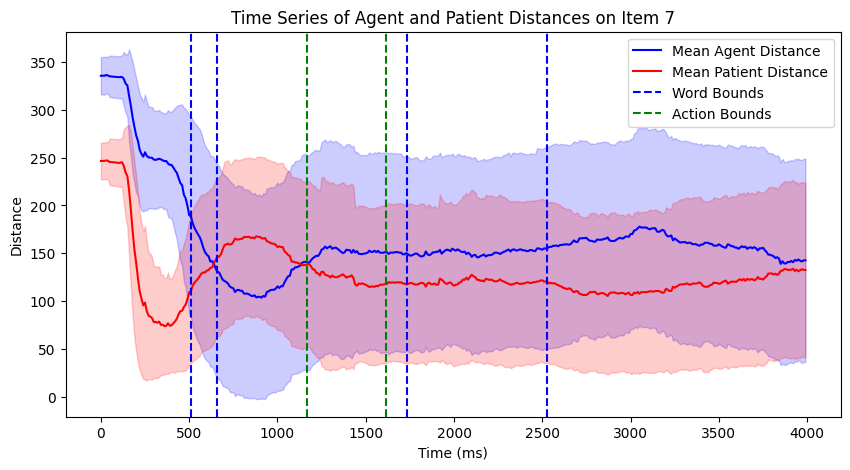

In [158]:
test_item = 7

# Filter DataFrame for the test item
edited_df = complete_df[complete_df['item'] == test_item]

# Extract mean onsets and offsets
the1_onset = results_df[results_df["item"] == test_item]["the1_onset"].mean()
agent_onset = results_df[results_df["item"] == test_item]["agent_onset"].mean()
agent_offset = results_df[results_df["item"] == test_item]["agent_offset"].mean()
the2_onset = results_df[results_df["item"] == test_item]["the2_onset"].mean()
patient_onset = results_df[results_df["item"] == test_item]["patient_onset"].mean()
patient_offset = results_df[results_df["item"] == test_item]["patient_offset"].mean()

# Convert 'a_dists' and 'b_dists' columns to NumPy arrays
a_dists_array = np.array(edited_df['a_dists'].tolist(), dtype=np.float64)
b_dists_array = np.array(edited_df['b_dists'].tolist(), dtype=np.float64)

# Compute mean and variance while ignoring NaNs
a_mean = np.nanmean(a_dists_array, axis=0)
a_var = np.nanvar(a_dists_array, axis=0)

b_mean = np.nanmean(b_dists_array, axis=0)
b_var = np.nanvar(b_dists_array, axis=0)

# Create time points (assuming 10ms intervals)
time_points = np.arange(0, len(a_mean) * 10, 10)  # in milliseconds

# Plot
plt.figure(figsize=(10, 5))

# Plot 'a_dists' in blue
line1, = plt.plot(time_points, a_mean, label="Mean Agent Distance", color='b')
plt.fill_between(time_points, 
                 a_mean - np.sqrt(a_var),  
                 a_mean + np.sqrt(a_var),  
                 color='b', alpha=0.2)

# Plot 'b_dists' in red
line2, = plt.plot(time_points, b_mean, label="Mean Patient Distance", color='r')
plt.fill_between(time_points, 
                 b_mean - np.sqrt(b_var),  
                 b_mean + np.sqrt(b_var),  
                 color='r', alpha=0.2)

# Add vertical lines for onsets and offsets
line3 = plt.axvline(x=the1_onset, color='b', linestyle='--', label="The1 Onset")
line4 = plt.axvline(x=agent_onset, color='b', linestyle='--', label="Agent Onset")
line5 = plt.axvline(x=agent_offset, color='g', linestyle='--', label="Agent Offset")
line6 = plt.axvline(x=the2_onset, color='g', linestyle='--', label="The2 Onset")
line7 = plt.axvline(x=patient_onset, color='b', linestyle='--', label="Patient Onset")
line8 = plt.axvline(x=patient_offset, color='b', linestyle='--', label="Patient Offset")

# Remove grid lines
plt.grid(False)

# Include only certain items
plt.legend([line1, line2, line4, line6], 
           ["Mean Agent Distance", "Mean Patient Distance", "Word Bounds", "Action Bounds"])

# Labels and Title
plt.xlabel("Time (ms)")
plt.ylabel("Distance")
plt.title(f"Time Series of Agent and Patient Distances on Item {test_item}")

# Show the plot
plt.show()



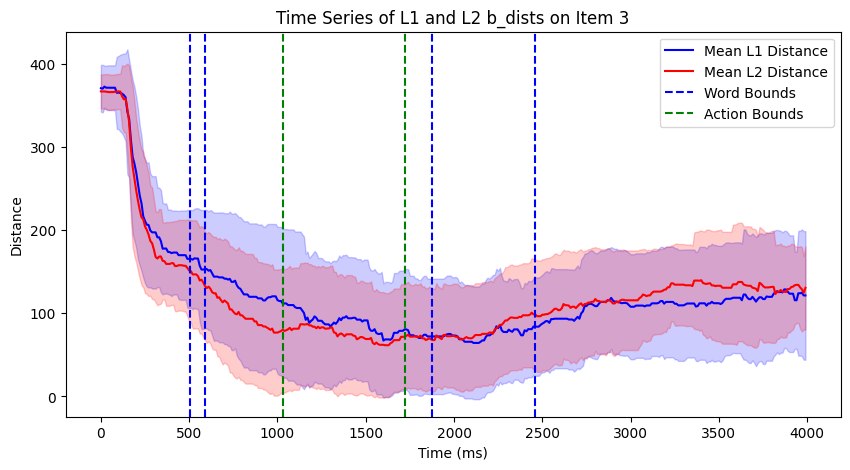

In [159]:
test_item = 3
dist_focus = 'b_dists' # Make this two shades of blue and a red version for patient

# Filter DataFrame for the test item
edited_df = complete_df[complete_df['item'] == test_item]
edited_df_L1 = edited_df[edited_df['participent_language'] == 'L1_participant']
edited_df_L2 = edited_df[edited_df['participent_language'] == 'L2_participant']
edited_df_BI = edited_df[edited_df['participent_language'] == 'BILINGUAL']

# Extract mean onsets and offsets
the1_onset = results_df[results_df["item"] == test_item]["the1_onset"].mean()
agent_onset = results_df[results_df["item"] == test_item]["agent_onset"].mean()
agent_offset = results_df[results_df["item"] == test_item]["agent_offset"].mean()
the2_onset = results_df[results_df["item"] == test_item]["the2_onset"].mean()
patient_onset = results_df[results_df["item"] == test_item]["patient_onset"].mean()
patient_offset = results_df[results_df["item"] == test_item]["patient_offset"].mean()

L1_array = np.array(edited_df_L1[dist_focus].tolist(), dtype=np.float64)
L2_array = np.array(edited_df_L2[dist_focus].tolist(), dtype=np.float64)
BI_array = np.array(edited_df_BI[dist_focus].tolist(), dtype=np.float64)

# Compute mean and variance while ignoring NaNs
L1_mean = np.nanmean(L1_array, axis=0)
L1_var = np.nanvar(L1_array, axis=0)

L2_mean = np.nanmean(L2_array, axis=0)
L2_var = np.nanvar(L2_array, axis=0)

BI_mean = np.nanmean(BI_array, axis=0)
BI_var = np.nanvar(BI_array, axis=0)

# Create time points (assuming 10ms intervals)
time_points = np.arange(0, len(L1_mean) * 10, 10)  # in milliseconds

# Plot
plt.figure(figsize=(10, 5))

line1, = plt.plot(time_points, L1_mean, label="Mean L1 Agent Distance", color='b')
plt.fill_between(time_points, 
                 L1_mean - np.sqrt(L1_var),  
                 L1_mean + np.sqrt(L1_var),  
                 color='b', alpha=0.2)

line2, = plt.plot(time_points, L2_mean, label="Mean L2 Agent Distance", color='r')
plt.fill_between(time_points, 
                 L2_mean - np.sqrt(L2_var),  
                 L2_mean + np.sqrt(L2_var),  
                 color='r', alpha=0.2)

#line3, = plt.plot(time_points, BI_mean, label="Mean BI Agent Distance", color='g')
#plt.fill_between(time_points, 
                 #BI_mean - np.sqrt(BI_var),  
                 #BI_mean + np.sqrt(BI_var),  
                 #color='g', alpha=0.2)

# Add vertical lines for onsets and offsets
line4 = plt.axvline(x=the1_onset, color='b', linestyle='--', label="The1 Onset")
line5 = plt.axvline(x=agent_onset, color='b', linestyle='--', label="Agent Onset")
line6 = plt.axvline(x=agent_offset, color='g', linestyle='--', label="Agent Offset")
line7 = plt.axvline(x=the2_onset, color='g', linestyle='--', label="The2 Onset")
line8 = plt.axvline(x=patient_onset, color='b', linestyle='--', label="Patient Onset")
line9 = plt.axvline(x=patient_offset, color='b', linestyle='--', label="Patient Offset")

# Remove grid lines
plt.grid(False)

# Include only certain items
plt.legend([line1, line2, line5, line7], 
           ["Mean L1 Distance", "Mean L2 Distance", "Word Bounds", "Action Bounds"])

# Labels and Title
plt.xlabel("Time (ms)")
plt.ylabel("Distance")
plt.title(f"Time Series of L1 and L2 {dist_focus} on Item {test_item}")

# Show the plot
plt.show()



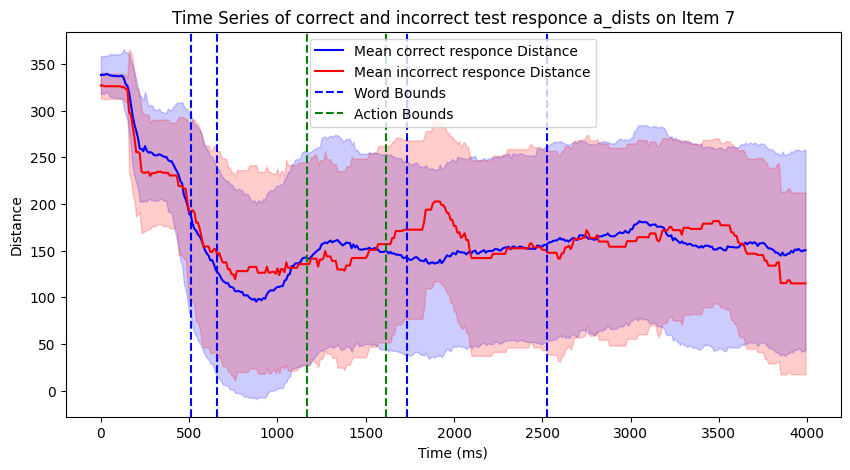

In [161]:
test_item = 7
dist_focus = 'a_dists'

# Filter DataFrame for the test item
edited_df = complete_df[complete_df['item'] == test_item]
edited_df_correct = edited_df[edited_df['test_accuracy'] == True]
edited_df_incorrect = edited_df[edited_df['test_accuracy'] == False]

# Extract mean onsets and offsets
the1_onset = results_df[results_df["item"] == test_item]["the1_onset"].mean()
agent_onset = results_df[results_df["item"] == test_item]["agent_onset"].mean()
agent_offset = results_df[results_df["item"] == test_item]["agent_offset"].mean()
the2_onset = results_df[results_df["item"] == test_item]["the2_onset"].mean()
patient_onset = results_df[results_df["item"] == test_item]["patient_onset"].mean()
patient_offset = results_df[results_df["item"] == test_item]["patient_offset"].mean()

correct_array = np.array(edited_df_correct[dist_focus].tolist(), dtype=np.float64)
incorrect_array = np.array(edited_df_incorrect[dist_focus].tolist(), dtype=np.float64)

# Compute mean and variance while ignoring NaNs
correct_mean = np.nanmean(correct_array, axis=0)
correct_var = np.nanvar(correct_array, axis=0)

incorrect_mean = np.nanmean(incorrect_array, axis=0)
incorrect_var = np.nanvar(incorrect_array, axis=0)

# Create time points (assuming 10ms intervals)
time_points = np.arange(0, len(correct_mean) * 10, 10)  # in milliseconds

# Plot
plt.figure(figsize=(10, 5))

line1, = plt.plot(time_points, correct_mean, label="Mean correct responce Distance", color='b')
plt.fill_between(time_points, 
                 correct_mean - np.sqrt(correct_var),  
                 correct_mean + np.sqrt(correct_var),  
                 color='b', alpha=0.2)

line2, = plt.plot(time_points, incorrect_mean, label="Mean incorrect responce Distance", color='r')
plt.fill_between(time_points, 
                 incorrect_mean - np.sqrt(incorrect_var),  
                 incorrect_mean + np.sqrt(incorrect_var),  
                 color='r', alpha=0.2)

# Add vertical lines for onsets and offsets
line4 = plt.axvline(x=the1_onset, color='b', linestyle='--', label="The1 Onset")
line5 = plt.axvline(x=agent_onset, color='b', linestyle='--', label="Agent Onset")
line6 = plt.axvline(x=agent_offset, color='g', linestyle='--', label="Agent Offset")
line7 = plt.axvline(x=the2_onset, color='g', linestyle='--', label="The2 Onset")
line8 = plt.axvline(x=patient_onset, color='b', linestyle='--', label="Patient Onset")
line9 = plt.axvline(x=patient_offset, color='b', linestyle='--', label="Patient Offset")

# Remove grid lines
plt.grid(False)

# Include only certain items
plt.legend([line1, line2, line5, line7], 
           ["Mean correct responce Distance", "Mean incorrect responce Distance", "Word Bounds", "Action Bounds"])

# Labels and Title
plt.xlabel("Time (ms)")
plt.ylabel("Distance")
plt.title(f"Time Series of correct and incorrect test responce {dist_focus} on Item {test_item}")

# Show the plot
plt.show()

In [ ]:
test_subitem = 'sub119_6'


# Filter DataFrame for the test item
edited_df = complete_df[complete_df['item'] == test_item]

# Extract mean onsets and offsets
the1_onset = results_df[results_df["item"] == test_item]["the1_onset"].mean()
agent_onset = results_df[results_df["item"] == test_item]["agent_onset"].mean()
agent_offset = results_df[results_df["item"] == test_item]["agent_offset"].mean()
the2_onset = results_df[results_df["item"] == test_item]["the2_onset"].mean()
patient_onset = results_df[results_df["item"] == test_item]["patient_onset"].mean()
patient_offset = results_df[results_df["item"] == test_item]["patient_offset"].mean()

# Convert 'a_dists' and 'b_dists' columns to NumPy arrays
a_dists_array = np.array(edited_df['a_dists'][0], dtype=np.float64)
b_dists_array = np.array(edited_df['b_dists'][0], dtype=np.float64)

# Compute mean and variance while ignoring NaNs
a_mean = np.nanmean(a_dists_array, axis=0)
a_var = np.nanvar(a_dists_array, axis=0)

b_mean = np.nanmean(b_dists_array, axis=0)
b_var = np.nanvar(b_dists_array, axis=0)

# Create time points (assuming 10ms intervals)
time_points = np.arange(0, len(a_mean) * 10, 10)  # in milliseconds

# Plot
plt.figure(figsize=(10, 5))

# Plot 'a_dists' in blue
line1, = plt.plot(time_points, a_mean, label="Mean Agent Distance", color='b')


# Add vertical lines for onsets and offsets
line3 = plt.axvline(x=the1_onset, color='b', linestyle='--', label="The1 Onset")
line4 = plt.axvline(x=agent_onset, color='b', linestyle='--', label="Agent Onset")
line5 = plt.axvline(x=agent_offset, color='g', linestyle='--', label="Agent Offset")
line6 = plt.axvline(x=the2_onset, color='g', linestyle='--', label="The2 Onset")
line7 = plt.axvline(x=patient_onset, color='b', linestyle='--', label="Patient Onset")
line8 = plt.axvline(x=patient_offset, color='b', linestyle='--', label="Patient Offset")

# Remove grid lines
plt.grid(False)

# Include only certain items
plt.legend([line1, line2, line4, line6], 
           ["Mean Agent Distance", "Mean Patient Distance", "Word Bounds", "Action Bounds"])

# Labels and Title
plt.xlabel("Time (ms)")
plt.ylabel("Distance")
plt.title(f"Time Series of Agent and Patient Distances on Item {test_item}")

# Show the plot
plt.show()